# 04 — Análisis Geoquímico
**Objetivo:** Correlación entre BH y diamantina, distribuciones de ley por zona mineralizada, correlación entre elementos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

DATA_PATH  = Path('../Documentacion/Referencias/Datos Demo')
BH_PATH    = DATA_PATH / 'Data_BH'
DRILL_PATH = DATA_PATH / 'Data_drill'

# BH
bh_collar = pd.read_csv(BH_PATH / 'collar.csv')
bh_assay  = pd.read_csv(BH_PATH / 'assay.csv')
bh_litho  = pd.read_csv(BH_PATH / 'litho.csv')

# Diamantina
dr_collar = pd.read_csv(DRILL_PATH / 'collar.csv')
dr_assay  = pd.read_csv(DRILL_PATH / 'assay.csv')

bh = bh_collar.merge(bh_assay, on='HOLEID').merge(bh_litho[['HOLEID','MINZONE','LITH1']], on='HOLEID', how='left')
dr = dr_collar.merge(dr_assay, on='HOLEID', how='left')

print(f'BH combinado: {bh.shape}')
print(f'Drill combinado: {dr.shape}')

BH combinado: (17210, 53)
Drill combinado: (32209, 49)


/tmp/ipykernel_95517/4248019746.py:20: DtypeWarning: Columns (0: AG) have mixed types. Specify dtype option on import or set low_memory=False.
  dr_assay  = pd.read_csv(DRILL_PATH / 'assay.csv')


## 1. Correlación entre elementos — BH

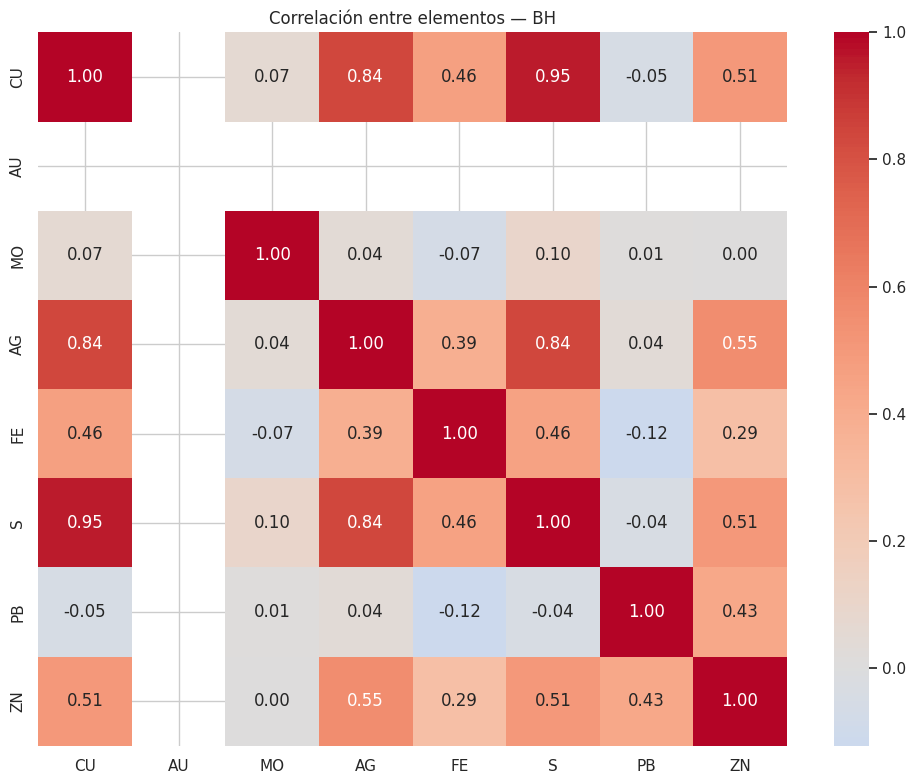

In [2]:
cols_geo = ['CU', 'AU', 'MO', 'AG', 'FE', 'S', 'PB', 'ZN']
cols_geo = [c for c in cols_geo if c in bh.columns]

bh_geo = bh[cols_geo].dropna(how='all')
corr = bh_geo.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación entre elementos — BH')
plt.tight_layout()
plt.show()

## 2. CU por zona mineralizada (MINZONE)

/tmp/ipykernel_95517/504737065.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


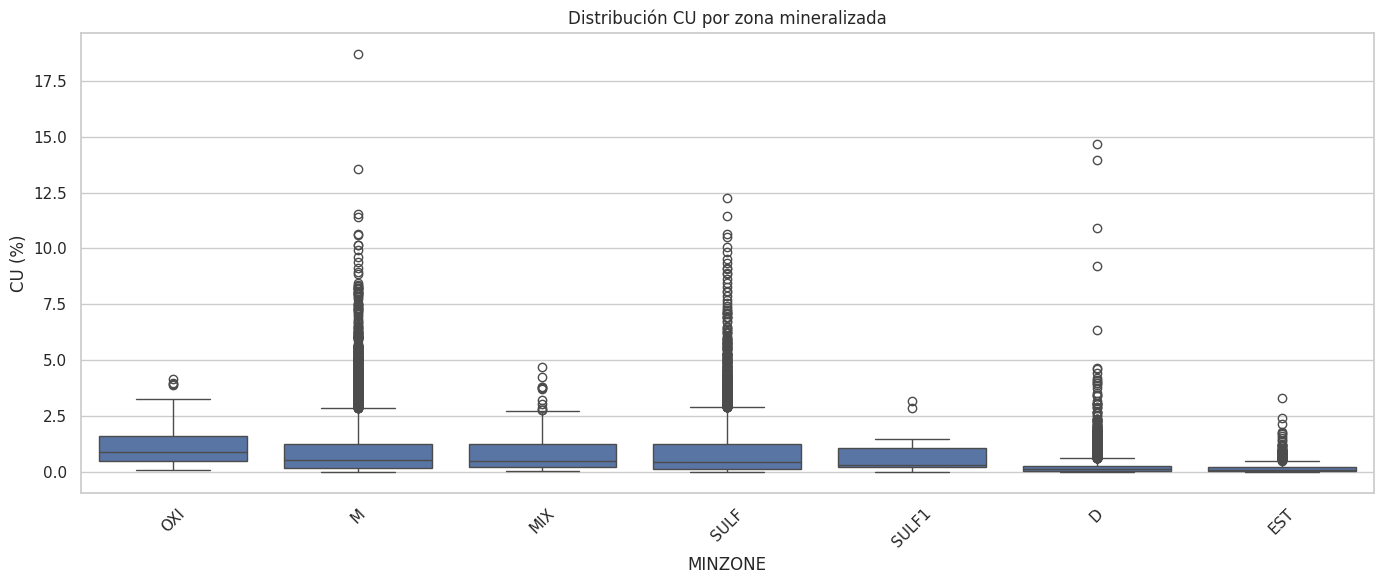

         count    mean     std  median
MINZONE                               
OXI        214  1.1570  0.8478   0.904
M         6295  1.0108  1.3242   0.524
SULF      4583  0.9373  1.2800   0.424
MIX        161  0.9021  0.9470   0.500
SULF1       15  0.8197  0.9839   0.310
D         4152  0.2709  0.5756   0.119
EST       1025  0.2024  0.2780   0.105


In [3]:
bh_valid = bh.dropna(subset=['CU', 'MINZONE'])

# Ordenar por mediana de CU
order = bh_valid.groupby('MINZONE')['CU'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=bh_valid, x='MINZONE', y='CU', order=order, ax=ax)
ax.set_title('Distribución CU por zona mineralizada')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_ylabel('CU (%)')
plt.tight_layout()
plt.show()

print(bh_valid.groupby('MINZONE')['CU'].agg(['count','mean','std','median']).round(4).sort_values('mean', ascending=False))

## 3. Comparación de leyes CU — BH vs Diamantina

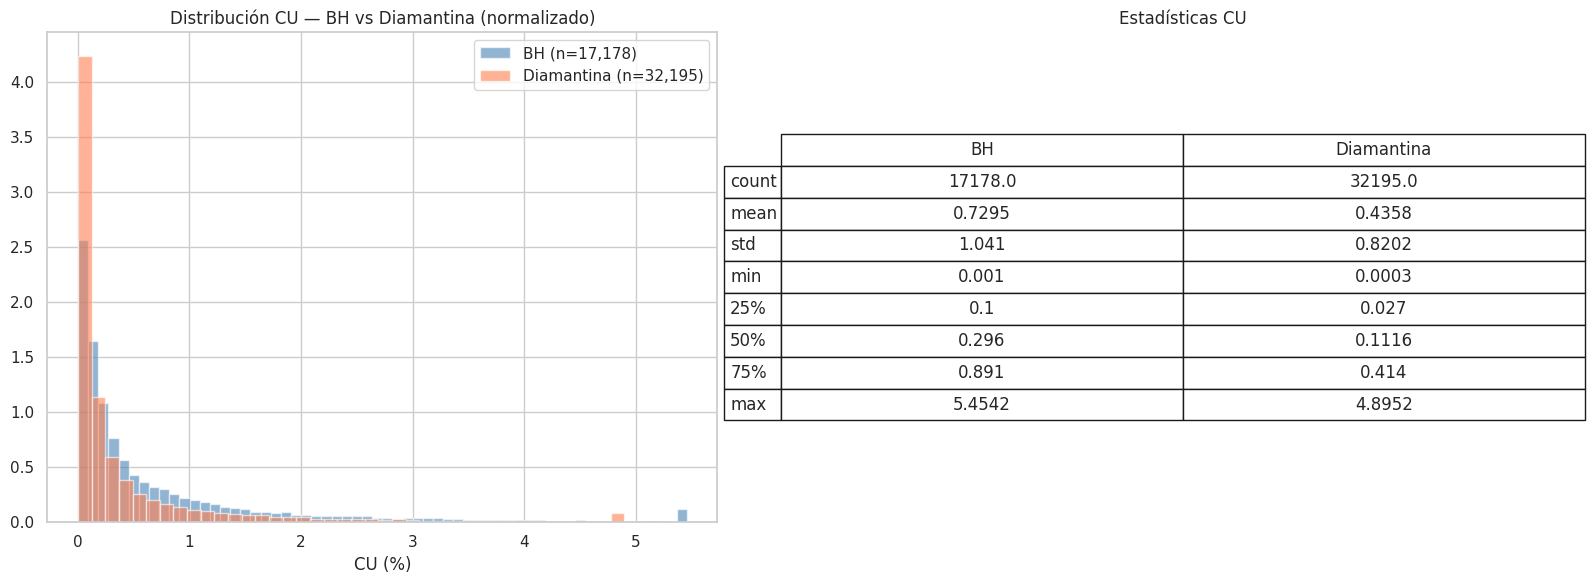

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bh_cu = bh['CU'].dropna().clip(upper=bh['CU'].quantile(0.99))
dr_cu = dr['CU'].dropna().clip(upper=dr['CU'].quantile(0.99))

# Histograma comparativo (normalizado)
axes[0].hist(bh_cu, bins=60, density=True, alpha=0.6, color='steelblue', label=f'BH (n={len(bh_cu):,})')
axes[0].hist(dr_cu, bins=40, density=True, alpha=0.6, color='coral', label=f'Diamantina (n={len(dr_cu):,})')
axes[0].set_title('Distribución CU — BH vs Diamantina (normalizado)')
axes[0].set_xlabel('CU (%)')
axes[0].legend()

# Stats comparativas
stats = pd.DataFrame({
    'BH': bh_cu.describe(),
    'Diamantina': dr_cu.describe()
}).round(4)
axes[1].axis('off')
tbl = axes[1].table(cellText=stats.values.round(4),
                     rowLabels=stats.index,
                     colLabels=stats.columns,
                     loc='center', cellLoc='center')
tbl.scale(1.2, 1.8)
axes[1].set_title('Estadísticas CU')

plt.tight_layout()
plt.show()

## 4. Ley CU vs MO — scatter por MINZONE

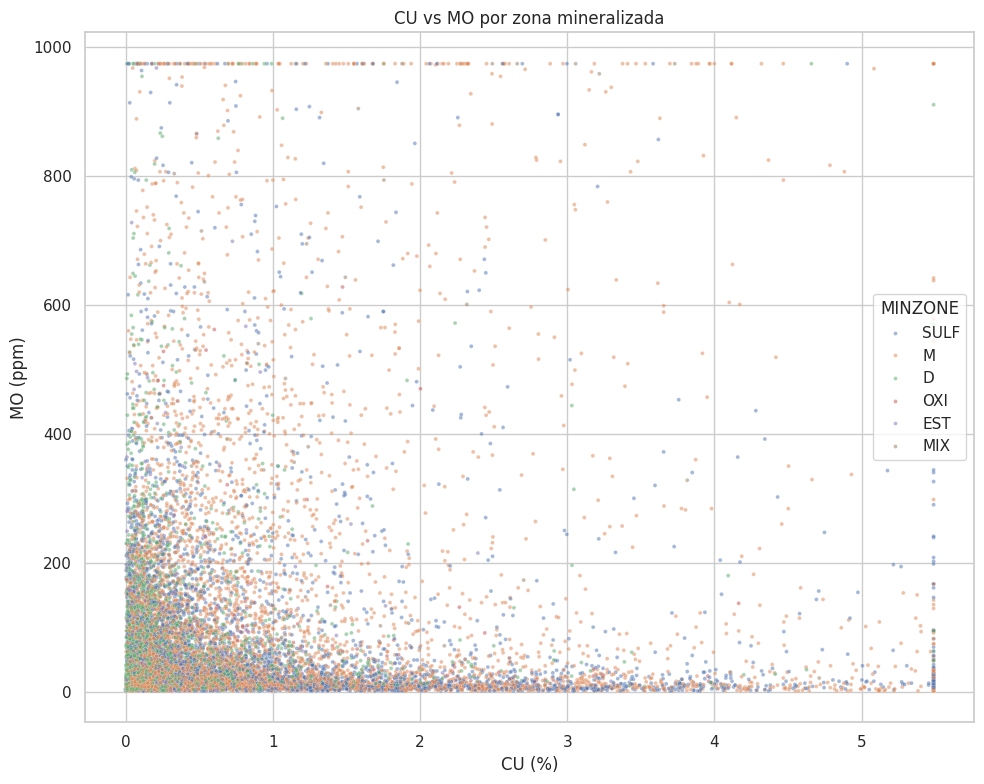

In [5]:
if 'MO' in bh.columns:
    bh_scatter = bh.dropna(subset=['CU', 'MO', 'MINZONE']).copy()
    bh_scatter['CU_clip'] = bh_scatter['CU'].clip(upper=bh_scatter['CU'].quantile(0.99))
    bh_scatter['MO_clip'] = bh_scatter['MO'].clip(upper=bh_scatter['MO'].quantile(0.99))

    fig, ax = plt.subplots(figsize=(10, 8))
    top_zones = bh_scatter['MINZONE'].value_counts().head(6).index
    sub = bh_scatter[bh_scatter['MINZONE'].isin(top_zones)]
    sns.scatterplot(data=sub, x='CU_clip', y='MO_clip', hue='MINZONE', s=8, alpha=0.5, ax=ax)
    ax.set_title('CU vs MO por zona mineralizada')
    ax.set_xlabel('CU (%)')
    ax.set_ylabel('MO (ppm)')
    plt.tight_layout()
    plt.show()